In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.float_format','{:.2f}'.format)

In [2]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [27]:
x = df[['area', 'bedrooms', 'bathrooms', 'stories']]
y = df[['price']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_test)

     area  bedrooms  bathrooms  stories
316  5900         4          2        2
77   6500         3          2        3
360  4040         2          1        1
90   5000         3          1        2
493  3960         3          1        1
..    ...       ...        ...      ...
172  8400         3          1        2
124  6525         3          2        4
388  3650         3          1        2
521  3635         2          1        1
503  4000         3          1        1

[137 rows x 4 columns]


In [4]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(x_test)
y_pred = y_pred.flatten()
y_test = y_test.squeeze()
results = pd.DataFrame({
    'Price': y_test.values,
    'Predicted': y_pred
})
results['error'] = results['Price'] - results['Predicted']
print(results)

       Price  Predicted       error
0    4060000 6231849.34 -2171849.34
1    6650000 6717145.81   -67145.81
2    3710000 3482721.95   227278.05
3    6440000 4463216.01  1976783.99
4    2800000 3637548.04  -837548.04
..       ...        ...         ...
132  5250000 5676397.59  -426397.59
133  5950000 7180643.40 -1230643.40
134  3500000 3981511.56  -481511.56
135  2408000 3338210.62  -930210.62
136  2660000 3651820.76  -991820.76

[137 rows x 3 columns]


In [6]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse, r2)

2172240802427.606 0.5286188620719235


to make the model better I will use somthing else, first I should study the relation between price and bathrooms and also stories, I think that I should use the scatter plot.

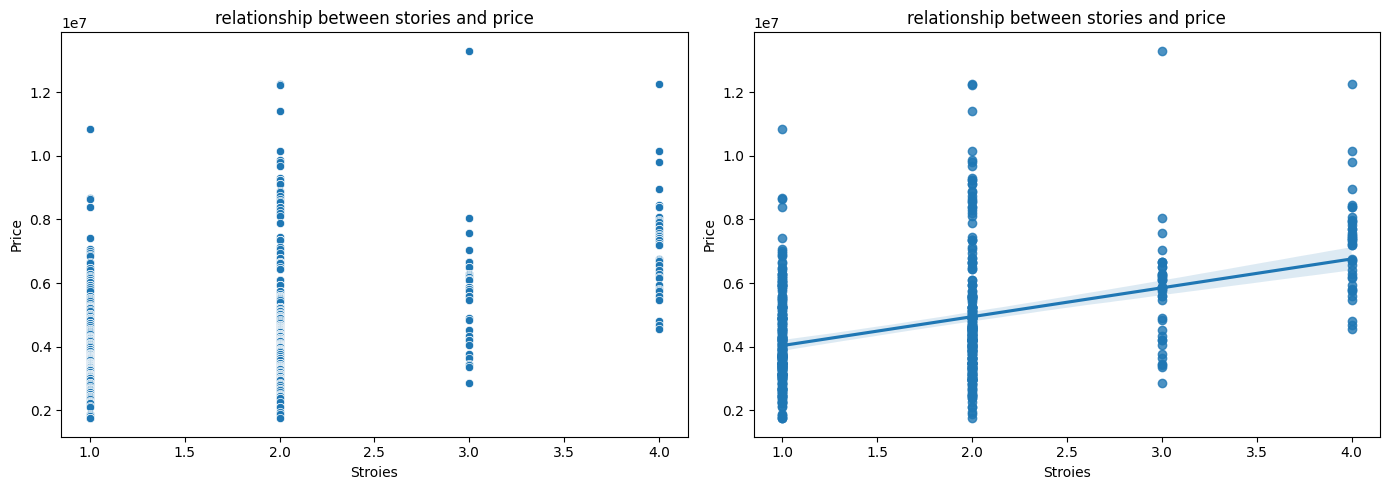

correlation:  0.42071236618861624


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='stories', y='price', data=df, ax=ax[0])
ax[0].set_title('relationship between stories and price')
ax[0].set_ylabel('Price')
ax[0].set_xlabel('Stroies')

sns.regplot(x='stories', y='price', data=df, ax=ax[1])
ax[1].set_title('relationship between stories and price')
ax[1].set_ylabel('Price')
ax[1].set_xlabel('Stroies')

plt.tight_layout()
plt.show()

print('correlation: ', df["stories"].corr(df["price"]))

corelation is not really good here, but let's try now bathrooms

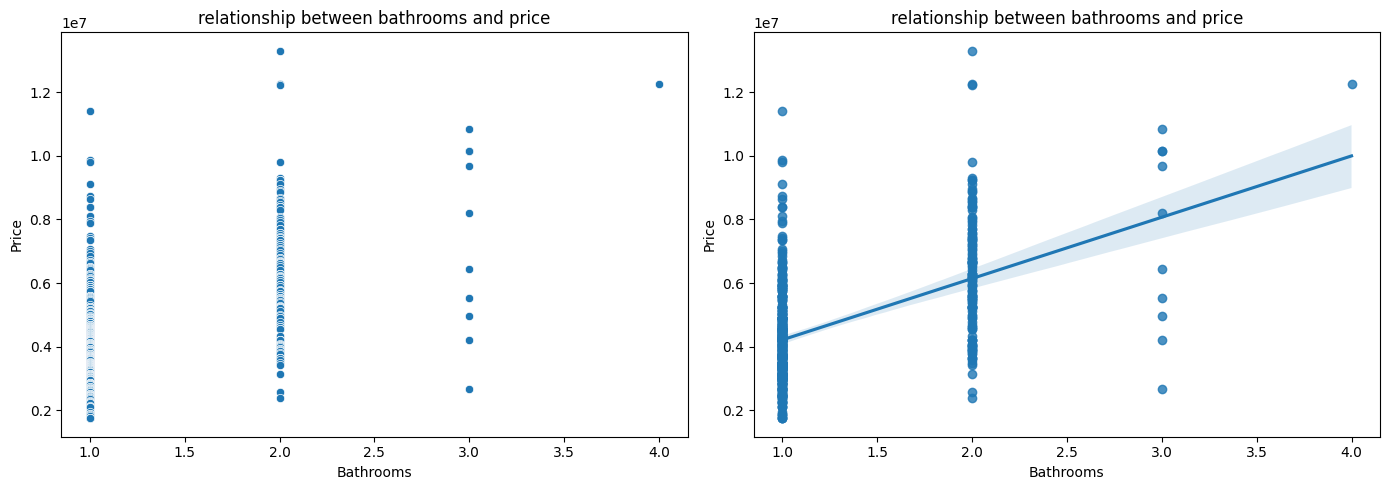

correlation:  0.517545339455011


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(x='bathrooms', y='price', data=df, ax=ax[0])
ax[0].set_title('relationship between bathrooms and price')
ax[0].set_ylabel('Price')
ax[0].set_xlabel('Bathrooms')

sns.regplot(x='bathrooms', y='price', data=df, ax=ax[1])
ax[1].set_title('relationship between bathrooms and price')
ax[1].set_ylabel('Price')
ax[1].set_xlabel('Bathrooms')

plt.tight_layout()
plt.show()

print('correlation: ', df["bathrooms"].corr(df["price"]))

I think that we can use this one

In [9]:
print('correlation betwwen bathrooms and price: ', df["bathrooms"].corr(df["price"]))
print('correlation between area and price: ', df["area"].corr(df["price"]))
print('correlation between bedrooms and price: ', df["bedrooms"].corr(df["price"]))
print('correlation between stories and price: ', df["stories"].corr(df["price"]))

correlation betwwen bathrooms and price:  0.517545339455011
correlation between area and price:  0.5359973457780797
correlation between bedrooms and price:  0.3664940257738689
correlation between stories and price:  0.42071236618861624


we'll use the onehotencoding to include also the furnishingstatus and airconditioning in the model.

In [10]:


df = pd.get_dummies(df, columns=['furnishingstatus', 'airconditioning', 'mainroad', 'guestroom', 'basement', 'prefarea', 'hotwaterheating'], drop_first=True)
# the one hot encoding using pandas
'''
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['furnishingstatus']])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(('furnishingstatus'))
)
df = pd.concat([df, encoded_df], axis=1)
df = df.drop('furnishingstatus', axis=1)
'''
# this one using sklearn, it's more difficult


"\nencoder = OneHotEncoder(sparse_output=False)\nencoded = encoder.fit_transform(df[['furnishingstatus']])\nencoded_df = pd.DataFrame(\n    encoded,\n    columns=encoder.get_feature_names_out(('furnishingstatus'))\n)\ndf = pd.concat([df, encoded_df], axis=1)\ndf = df.drop('furnishingstatus', axis=1)\n"

In [11]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished',
       'airconditioning_yes', 'mainroad_yes', 'guestroom_yes', 'basement_yes',
       'prefarea_yes', 'hotwaterheating_yes'],
      dtype='object')


now we'll train another model and see what will happend

In [24]:
a = df[['area', 'bedrooms', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished',
       'airconditioning_yes', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes',
       'prefarea_yes', 'hotwaterheating_yes']]
b = df[['price']]

a_train, a_test, b_train, b_test = train_test_split(x, y, test_size=0.4, random_state=42)

# the second model

model2 = LinearRegression()
model2.fit(a_train, b_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
b_pred = model2.predict(a_test)
b_pred = b_pred.flatten()
b_test = b_test.squeeze()
res = pd.DataFrame({
    'Price': b_test.values,
    'Predicted': b_pred
})
res['error'] = res['Price'] - res['Predicted']
print(res)

       Price  Predicted       error
0    4060000 6067472.65 -2007472.65
1    6650000 6532312.37   117687.63
2    3710000 3451385.22   258614.78
3    6440000 4485653.51  1954346.49
4    2800000 3638328.12  -838328.12
..       ...        ...         ...
213  5215000 5312949.91   -97949.91
214  7420000 7342033.38    77966.62
215  6107500 4497082.62  1610417.38
216  7980000 8145688.14  -165688.14
217  5495000 4908129.56   586870.44

[218 rows x 3 columns]


In [26]:
mse = mean_squared_error(b_test, b_pred)
r2 = r2_score(b_test, b_pred)

print(mse, r2)

2122795528699.5417 0.5426637419634706


I thought this will make it better but there is no chnagement, anyway I will create a simple page to predict the price.

In [28]:
test = [{
    'area': 4500,
    'bedrooms': 3,  
    'bathrooms': 1,
    'stories': 2
}]
data = pd.DataFrame(test)

print(model.predict(data))

[[4284806.95457936]]


this is just a simple model and you can find the data processing of this dataset in another repo: https://github.com/issamsensi/Data-Mining-Tp